# From Language Models to Genome Models: SNP Effect Prediction with Foundation Models

**AI for Medicine**

This notebook applies the same intellectual spine as clinical NLP — **tokenization, embeddings, attention, pretraining, transfer learning** — to genomics. Instead of clinical text, we work with DNA sequences. Instead of next-token prediction, we use masked language modeling. Instead of text generation, we predict whether a single-nucleotide polymorphism (SNP) causally affects gene expression.

**What you will learn:**
1. Explore an eQTL SNP dataset with ref/alt DNA sequences and tissue labels
2. Understand DNA tokenization with k-mers vs one-hot encoding
3. Extract frozen embeddings from a pretrained Nucleotide Transformer
4. Train classifiers (logistic regression and MLP) on frozen embeddings
5. Fine-tune the foundation model efficiently with LoRA
6. Explore sequence-to-function models (Enformer, DeepSEA)
7. Interpret model predictions with attention and saliency maps

In [1]:
# ── Section 0: Setup and Environment ──────────────────────────────────────────
import sys, subprocess

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

pip_install([
    "-U", "transformers<5.0", "datasets<3.0", "tokenizers", "peft",
    "accelerate", "huggingface_hub", "scikit-learn", "pyfaidx",
])

import torch, transformers, datasets, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, HTML
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix

print(f"torch: {torch.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"numpy: {np.__version__}")

# GPU detection
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU — running on CPU (embedding extraction will be slow)")

# Toggle: set True to skip training and load precomputed results
USE_PRECOMPUTED = False

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Matplotlib defaults
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})
sns.set_style("whitegrid")

torch: 2.10.0+cu128
transformers: 4.57.6
numpy: 2.0.2
GPU: Tesla T4


In [2]:
# Helper functions used throughout the notebook

def plot_training_curve(log_history, metric="loss", title="Training Loss"):
    """Plot train (and optionally test) metrics from Trainer log_history."""
    train_steps = [e["step"] for e in log_history if metric in e]
    train_values = [e[metric] for e in log_history if metric in e]
    eval_metric = "eval_" + metric
    eval_steps = [e["step"] for e in log_history if eval_metric in e]
    eval_values = [e[eval_metric] for e in log_history if eval_metric in e]

    plt.figure(figsize=(8, 4))
    plt.plot(train_steps, train_values, linewidth=2, color="steelblue", label="Train")
    if eval_steps:
        plt.plot(eval_steps, eval_values, linewidth=2, color="coral", marker="o",
                 markersize=5, label="Test")
        plt.legend()
    plt.xlabel("Step")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title)
    plt.tight_layout()
    plt.show()


def display_comparison_table(rows, columns, title=""):
    """Render an HTML table for side-by-side comparison."""
    html = f'<h3 style="color:black;">{title}</h3>' if title else ""
    html += '<table style="width:100%; border-collapse:collapse; font-size:13px; color:black;">'
    html += "<tr>" + "".join(
        f'<th style="border:1px solid #ccc; padding:8px; background:#f0f0f0; color:black;">{c}</th>'
        for c in columns
    ) + "</tr>"
    for row in rows:
        html += "<tr>" + "".join(
            f'<td style="border:1px solid #ccc; padding:8px; vertical-align:top; white-space:pre-wrap; color:black;">{cell}</td>'
            for cell in row
        ) + "</tr>"
    html += "</table>"
    display(HTML(html))


@torch.no_grad()
def extract_embeddings(model, tokenizer, sequences, device, batch_size=16):
    """Extract mean-pooled hidden-state embeddings from a masked LM."""
    model.eval()
    all_embs = []
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i:i+batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512)
        enc = {k: v.to(device) for k, v in enc.items()}
        out = model(**enc, output_hidden_states=True)
        # Mean-pool the last hidden state (exclude padding)
        hidden = out.hidden_states[-1]  # (B, seq_len, dim)
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
        all_embs.append(pooled.cpu())
    return torch.cat(all_embs, dim=0)


def find_snp_position(ref_seq, alt_seq):
    """Find the position where ref and alt sequences differ."""
    for i, (r, a) in enumerate(zip(ref_seq, alt_seq)):
        if r != a:
            return i
    return -1

---

### NLP → Genomics: Concept Mapping

| Clinical NLP | Genomics |
|---|---|
| Text tokenization (BPE, subwords) | DNA tokenization (6-mer k-mers) |
| Word/subword embeddings | K-mer embeddings |
| Decoder-only transformer (GPT) | Encoder-only transformer (BERT-style) |
| Next-token prediction (CLM) | Masked language modeling (MLM) |
| SFT / GRPO fine-tuning | Frozen probe + LoRA fine-tuning |
| Clinical note generation | SNP effect prediction |

**Why SNPs are different from text:** DNA is a discrete alphabet (A/C/G/T), mutations are point changes, and the functional effect of a variant depends on long-range regulatory context (thousands of base pairs away).

---
## Section 1: Data Tour — The eQTL SNP Task

### What is an eQTL?

An **expression Quantitative Trait Locus (eQTL)** is a genomic variant that affects the expression level of a gene. Our task is **binary classification**: given a SNP in its sequence context, does it causally affect gene expression in a particular tissue?

```
DNA:  ...ACGTACGT[ A → G ]CGTACGTACGT...
                  ↑ SNP
Tissue: Whole_Blood
Label:  1 (causal) or 0 (non-causal)
```

We use the **Genomics Long-Range Benchmark** eQTL subset from HuggingFace. Each example includes:
- `ref_forward_sequence` / `alt_forward_sequence` — ~6,000 bp windows centered on the variant
- `tissue` — the tissue in which causality was assessed
- `label` — 1 (causal eQTL) or 0 (non-causal)

In [3]:
import os, warnings
from datasets import load_dataset, load_from_disk

CACHE_DIR = "cached_eqtl_subset"

if os.path.exists(CACHE_DIR):
    print("Loading cached subset (instant)...")
    train_ds = load_from_disk(os.path.join(CACHE_DIR, "train"))
    test_ds = load_from_disk(os.path.join(CACHE_DIR, "test"))
else:
    print("First run: downloading & processing (a few minutes)...")
    warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")
    full_dataset = load_dataset(
        "InstaDeepAI/genomics-long-range-benchmark",
        task_name="variant_effect_causal_eqtl",
        sequence_length=2048,
        trust_remote_code=True,
        token=False,
    )
    train_ds = full_dataset["train"].shuffle(seed=SEED).select(range(4000))
    test_ds = full_dataset["test"].shuffle(seed=SEED).select(range(800))
    os.makedirs(CACHE_DIR, exist_ok=True)
    train_ds.save_to_disk(os.path.join(CACHE_DIR, "train"))
    test_ds.save_to_disk(os.path.join(CACHE_DIR, "test"))
    print("Subset cached — future runs will be instant.")
    del full_dataset

print(f"Working subsets — train: {len(train_ds)}, test: {len(test_ds)}")

First run: downloading & processing (a few minutes)...


hg38.fa.gz: 938MB [00:12, 78.3MB/s]                              


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/800 [00:00<?, ? examples/s]

Subset cached — future runs will be instant.
Working subsets — train: 4000, test: 800


In [4]:
# Inspect one example
ex = train_ds[0]

# Pretty-print as HTML table
fields = ["chromosome", "position", "tissue", "distance_to_nearest_tss", "label"]
html = '<table style="border-collapse:collapse; font-size:13px; color:black;">'
for f in fields:
    html += f'<tr><td style="border:1px solid #ccc; padding:6px; font-weight:bold; background:#f0f0f0;">{f}</td>'
    html += f'<td style="border:1px solid #ccc; padding:6px;">{ex[f]}</td></tr>'
html += '</table>'
display(HTML(html))

# Find and show SNP position
ref = ex["ref_forward_sequence"]
alt = ex["alt_forward_sequence"]
snp_pos = find_snp_position(ref, alt)
window = 10
print(f"\nSequence length: {len(ref)}")
print(f"SNP position: {snp_pos}")
print(f"\nRef: ...{ref[max(0,snp_pos-window):snp_pos]}[{ref[snp_pos]}]{ref[snp_pos+1:snp_pos+window+1]}...")
print(f"Alt: ...{alt[max(0,snp_pos-window):snp_pos]}[{alt[snp_pos]}]{alt[snp_pos+1:snp_pos+window+1]}...")

chromosome,16
position,11976565
tissue,Spleen
distance_to_nearest_tss,68
label,1



Sequence length: 2048
SNP position: 1024

Ref: ...GTCTCGGGTT[T]ACCCTGAGTC...
Alt: ...GTCTCGGGTT[C]ACCCTGAGTC...


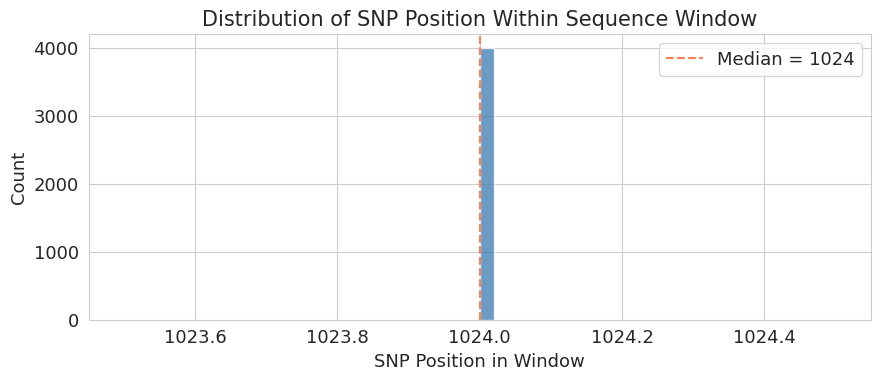

→ Teaching point: the SNP is typically centered in the window


In [5]:
# ── Visualization 1: SNP position within window ──
snp_positions = [find_snp_position(ex["ref_forward_sequence"], ex["alt_forward_sequence"])
                 for ex in train_ds]

plt.figure(figsize=(9, 4))
plt.hist(snp_positions, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(np.median(snp_positions), color="coral", linestyle="--", label=f"Median = {np.median(snp_positions):.0f}")
plt.xlabel("SNP Position in Window")
plt.ylabel("Count")
plt.title("Distribution of SNP Position Within Sequence Window")
plt.legend()
plt.tight_layout()
plt.show()
print("→ Teaching point: the SNP is typically centered in the window")

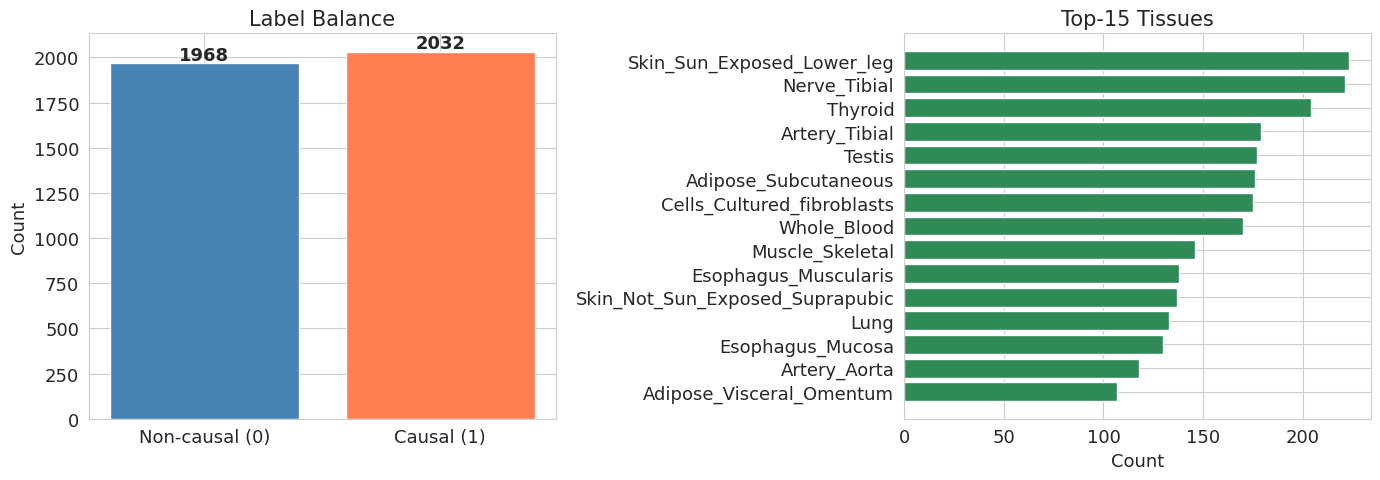

In [6]:
# ── Visualization 2: Label balance + tissue distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: label balance
labels = [ex["label"] for ex in train_ds]
counts = pd.Series(labels).value_counts().sort_index()
axes[0].bar(["Non-causal (0)", "Causal (1)"], counts.values, color=["steelblue", "coral"], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_title("Label Balance")

# Panel 2: top-15 tissues
tissues = [ex["tissue"] for ex in train_ds]
tissue_counts = pd.Series(tissues).value_counts().head(15)
axes[1].barh(tissue_counts.index[::-1], tissue_counts.values[::-1], color="seagreen", edgecolor="white")
axes[1].set_xlabel("Count")
axes[1].set_title("Top-15 Tissues")

plt.tight_layout()
plt.show()

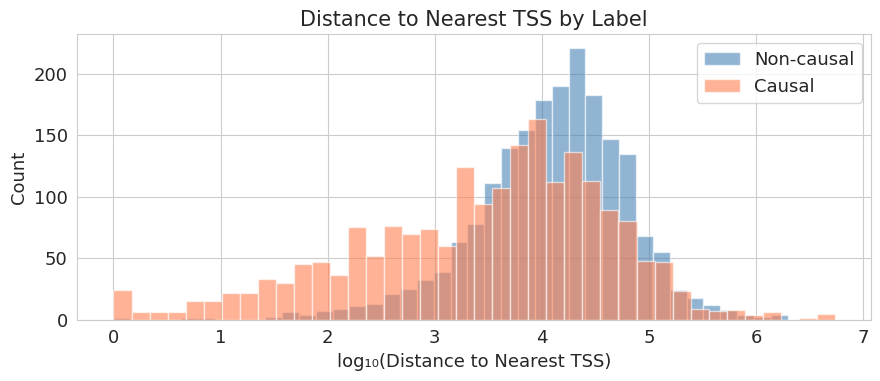

→ Teaching point: causal variants tend to be closer to transcription start sites


In [7]:
# ── Visualization 3: Distance-to-TSS by label ──
df = pd.DataFrame({
    "distance_to_nearest_tss": [ex["distance_to_nearest_tss"] for ex in train_ds],
    "label": [ex["label"] for ex in train_ds],
})
df["log_distance"] = np.log10(df["distance_to_nearest_tss"].clip(lower=1))

plt.figure(figsize=(9, 4))
for label, color, name in [(0, "steelblue", "Non-causal"), (1, "coral", "Causal")]:
    subset = df[df["label"] == label]
    plt.hist(subset["log_distance"], bins=40, alpha=0.6, color=color, label=name, edgecolor="white")
plt.xlabel("log₁₀(Distance to Nearest TSS)")
plt.ylabel("Count")
plt.title("Distance to Nearest TSS by Label")
plt.legend()
plt.tight_layout()
plt.show()
print("→ Teaching point: causal variants tend to be closer to transcription start sites")

### Why chromosome-held-out evaluation?

In genomics, **random train/test splits are dangerous**. Nearby variants on the same chromosome are correlated due to **linkage disequilibrium (LD)** — they tend to be inherited together. A random split would leak information from train to test.

The Genomics Long-Range Benchmark uses **chromosome-held-out splits**: entire chromosomes are reserved for testing. This ensures the model must generalize across genomic regions, not memorize local patterns.

---
## Section 2: DNA Tokenization and Genomic Foundation Models

Two main approaches to representing DNA for deep learning:

### Style A: Genomic Language Models (DNABERT, Nucleotide Transformer)
- Tokenize DNA into **k-mers** (e.g., non-overlapping 6-mers)
- Learn embeddings via **masked language modeling (MLM)**
- Vocabulary ≈ 4⁶ + special tokens ≈ 4,101 tokens

**MLM objective** (contrast with causal LM used in text generation):

$$P(x_i \mid x_{\setminus i}) \quad \text{(predict masked token from context on both sides)}$$

### Style B: One-hot encoding (classic approach)
- Each base (A/C/G/T) → 4-dimensional binary vector
- No vocabulary to learn — keeps single-base resolution
- Used in DeepSEA, Basenji, and many regulatory genomics models

In [8]:
# Load the Nucleotide Transformer tokenizer
from transformers import AutoTokenizer

nt_model_name = "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"
tokenizer = AutoTokenizer.from_pretrained(nt_model_name, trust_remote_code=True)

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Model max length: {tokenizer.model_max_length}")

# Show special tokens
print(f"\nSpecial tokens:")
for name in ["bos_token", "eos_token", "pad_token", "mask_token", "unk_token"]:
    tok = getattr(tokenizer, name, None)
    print(f"  {name}: {tok!r}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

Vocabulary size: 4107
Model max length: 2048

Special tokens:
  bos_token: None
  eos_token: None
  pad_token: '<pad>'
  mask_token: '<mask>'
  unk_token: '<unk>'


In [9]:
# Tokenize one ref and one alt sequence step-by-step
ex = train_ds[0]
ref_seq = ex["ref_forward_sequence"][:60]  # Take first 60 bases for clarity
alt_seq = ex["alt_forward_sequence"][:60]

# Step 1: Raw DNA
print("Step 1 — Raw DNA (first 60 bases):")
print(f"  Ref: {ref_seq}")
print(f"  Alt: {alt_seq}")

# Step 2: Tokenize → see the 6-mer tokens
ref_tokens = tokenizer.tokenize(ref_seq)
alt_tokens = tokenizer.tokenize(alt_seq)
print(f"\nStep 2 — 6-mer tokens:")
print(f"  Ref tokens ({len(ref_tokens)}): {ref_tokens}")
print(f"  Alt tokens ({len(alt_tokens)}): {alt_tokens}")

# Step 3: Convert to IDs
ref_ids = tokenizer.encode(ref_seq)
alt_ids = tokenizer.encode(alt_seq)
print(f"\nStep 3 — Token IDs:")
print(f"  Ref IDs: {ref_ids}")
print(f"  Alt IDs: {alt_ids}")

# Highlight differences
diffs = [(i, r, a) for i, (r, a) in enumerate(zip(ref_tokens, alt_tokens)) if r != a]
if diffs:
    print(f"\nDiffering tokens ({len(diffs)}):")
    for pos, r, a in diffs:
        print(f"  Position {pos}: {r!r} → {a!r}")

Step 1 — Raw DNA (first 60 bases):
  Ref: TCTCCACCCTGCCCCCATTATAATTCATTCTCATCCCAGGAAGAGCCATTTTTGTTGTTG
  Alt: TCTCCACCCTGCCCCCATTATAATTCATTCTCATCCCAGGAAGAGCCATTTTTGTTGTTG

Step 2 — 6-mer tokens:
  Ref tokens (10): ['TCTCCA', 'CCCTGC', 'CCCCAT', 'TATAAT', 'TCATTC', 'TCATCC', 'CAGGAA', 'GAGCCA', 'TTTTTG', 'TTGTTG']
  Alt tokens (10): ['TCTCCA', 'CCCTGC', 'CCCCAT', 'TATAAT', 'TCATTC', 'TCATCC', 'CAGGAA', 'GAGCCA', 'TTTTTG', 'TTGTTG']

Step 3 — Token IDs:
  Ref IDs: [3, 1646, 2724, 2727, 1095, 1564, 1568, 2294, 3310, 1373, 1501]
  Alt IDs: [3, 1646, 2724, 2727, 1095, 1564, 1568, 2294, 3310, 1373, 1501]


In [10]:
# ── Visualization 4: Color-coded ref vs alt tokenization ──
ex = train_ds[0]
ref_seq = ex["ref_forward_sequence"]
alt_seq = ex["alt_forward_sequence"]
snp_pos = find_snp_position(ref_seq, alt_seq)

# Tokenize around the SNP (take a window)
start = max(0, snp_pos - 30)
end = min(len(ref_seq), snp_pos + 30)
ref_window = ref_seq[start:end]
alt_window = alt_seq[start:end]

ref_toks = tokenizer.tokenize(ref_window)
alt_toks = tokenizer.tokenize(alt_window)

def colorize_tokens(tokens_a, tokens_b, label):
    html = f'<div style="font-family:monospace; font-size:14px; margin:5px 0; color:black;"><b>{label}:</b> '
    for i, tok in enumerate(tokens_a):
        if i < len(tokens_b) and tok != tokens_b[i]:
            html += f'<span style="background:#ff6b6b; padding:2px 3px; border-radius:3px; color:white;">{tok}</span> '
        else:
            html += f'<span style="background:#e8e8e8; padding:2px 3px; border-radius:3px;">{tok}</span> '
    html += '</div>'
    return html

html = '<h4 style="color:black;">K-mer Tokenization: Ref vs Alt (around SNP)</h4>'
html += colorize_tokens(ref_toks, alt_toks, "Ref")
html += colorize_tokens(alt_toks, ref_toks, "Alt")
html += '<p style="font-size:12px; color:gray;">Red = tokens that differ between ref and alt</p>'
display(HTML(html))

### K-mer Tokenization Explained

The Nucleotide Transformer uses **non-overlapping 6-mers**: the DNA sequence is split into consecutive chunks of 6 bases each.

- Vocabulary = 4⁶ = 4,096 possible 6-mers + special tokens ≈ 4,101
- A single SNP changes **at most one 6-mer token** (the one containing the variant position)
- This is fundamentally different from BPE tokenization in NLP where subword boundaries are learned from data

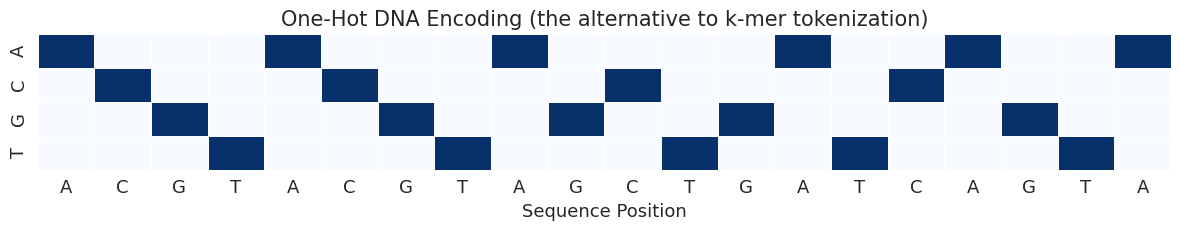

→ This is what DeepSEA and Enformer see as input — no tokenizer needed


In [11]:
# ── Visualization 5: One-hot DNA encoding heatmap ──
seq_snippet = "ACGTACGTAGCTGATCAGTA"
base_to_idx = {"A": 0, "C": 1, "G": 2, "T": 3}
onehot = np.zeros((4, len(seq_snippet)))
for j, base in enumerate(seq_snippet):
    onehot[base_to_idx[base], j] = 1

fig, ax = plt.subplots(figsize=(12, 2.5))
sns.heatmap(onehot, ax=ax, cmap="Blues", cbar=False, linewidths=0.5, linecolor="white",
            xticklabels=list(seq_snippet), yticklabels=["A", "C", "G", "T"])
ax.set_title("One-Hot DNA Encoding (the alternative to k-mer tokenization)")
ax.set_xlabel("Sequence Position")
plt.tight_layout()
plt.show()
print("→ This is what DeepSEA and Enformer see as input — no tokenizer needed")

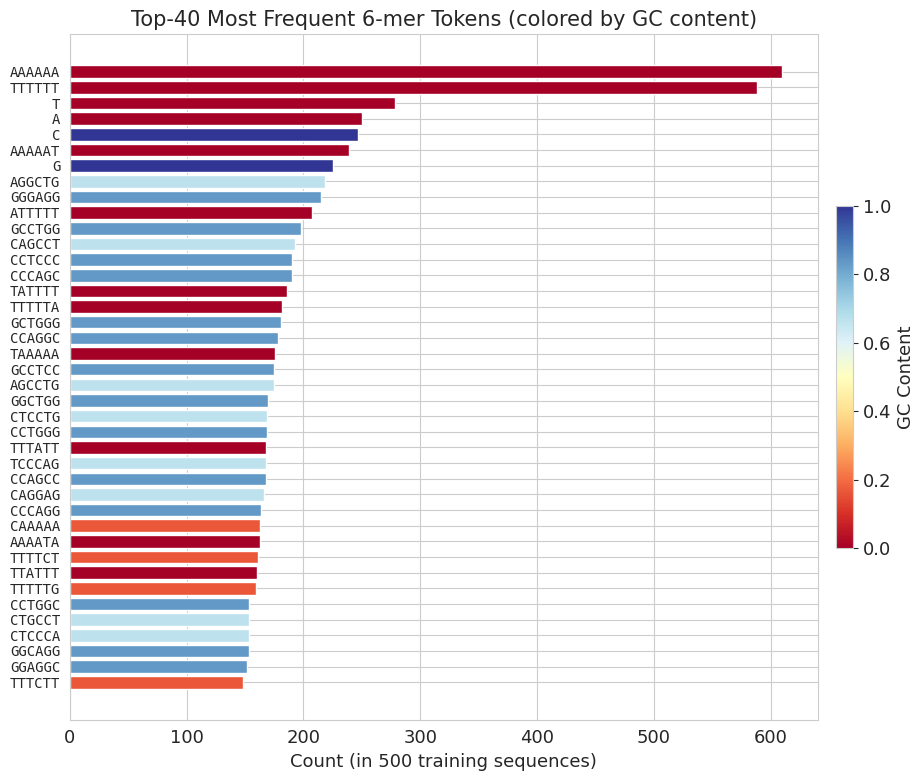

In [12]:
# ── Visualization 6: Top-40 most frequent 6-mer tokens ──
from collections import Counter

# Count 6-mers across a sample of sequences
kmer_counter = Counter()
for i in range(min(500, len(train_ds))):
    seq = train_ds[i]["ref_forward_sequence"]
    tokens = tokenizer.tokenize(seq)
    kmer_counter.update(tokens)

top40 = kmer_counter.most_common(40)
kmers, counts = zip(*top40)

# Color by GC content
def gc_content(kmer):
    kmer_clean = kmer.strip()
    if len(kmer_clean) == 0:
        return 0
    return sum(1 for b in kmer_clean if b in "GCgc") / len(kmer_clean)

colors = [plt.cm.RdYlBu(gc_content(k)) for k in kmers]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(kmers)-1, -1, -1)
ax.barh(y_pos, counts, color=colors, edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(kmers, fontsize=10, fontfamily="monospace")
ax.set_xlabel("Count (in 500 training sequences)")
ax.set_title("Top-40 Most Frequent 6-mer Tokens (colored by GC content)")

# Add colorbar
sm = plt.cm.ScalarMappable(cmap="RdYlBu", norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("GC Content")

plt.tight_layout()
plt.show()

In [49]:
# Compatibility shim: newer transformers removed this function from pytorch_utils
import transformers.pytorch_utils as _pu
if not hasattr(_pu, "find_pruneable_heads_and_indices"):
    def find_pruneable_heads_and_indices(heads, n_heads, head_size, already_pruned_heads):
        mask = torch.ones(n_heads, head_size)
        heads = set(heads) - already_pruned_heads
        for head in heads:
            head = head - sum(1 if h < head else 0 for h in already_pruned_heads)
            mask[head] = 0
        mask = mask.view(-1).contiguous().eq(1)
        index = torch.arange(len(mask))[mask].long()
        return heads, index
    _pu.find_pruneable_heads_and_indices = find_pruneable_heads_and_indices

# Token IDs → embeddings via pretrained model
from transformers import AutoModelForMaskedLM

nt_model = AutoModelForMaskedLM.from_pretrained(nt_model_name, trust_remote_code=True)
nt_model = nt_model.to(device)
nt_model.eval()

# Embed a single short sequence to show shapes
demo_seq = train_ds[0]["ref_forward_sequence"][:60]
enc = tokenizer(demo_seq, return_tensors="pt").to(device)
with torch.no_grad():
    out = nt_model(**enc, output_hidden_states=True)

print(f"Input token IDs shape: {enc['input_ids'].shape}")
print(f"Number of hidden layers: {len(out.hidden_states)}")
print(f"Last hidden state shape: {out.hidden_states[-1].shape}")
print(f"Embedding dimension: {out.hidden_states[-1].shape[-1]}")

Input token IDs shape: torch.Size([1, 11])
Number of hidden layers: 13
Last hidden state shape: torch.Size([1, 11, 512])
Embedding dimension: 512


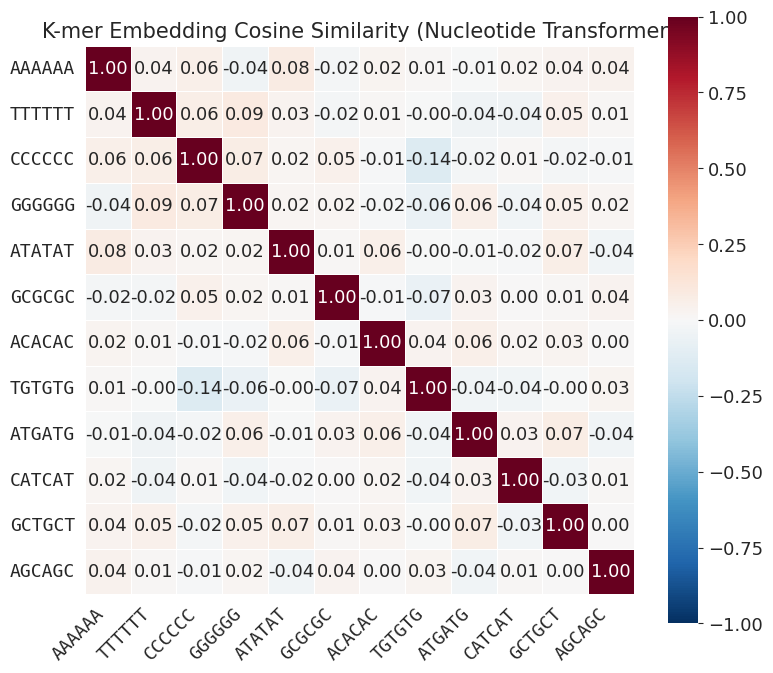

In [50]:
# ── Visualization 7: K-mer embedding cosine similarity heatmap ──
# Select interesting k-mers: complementary pairs, AT-rich, GC-rich
selected_kmers = [
    "AAAAAA", "TTTTTT", "CCCCCC", "GGGGGG",
    "ATATAT", "GCGCGC", "ACACAC", "TGTGTG",
    "ATGATG", "CATCAT", "GCTGCT", "AGCAGC",
]

# Get embedding for each k-mer from the model's embedding layer
embed_layer = nt_model.get_input_embeddings()
kmer_embs = []
valid_kmers = []
for kmer in selected_kmers:
    ids = tokenizer.encode(kmer, add_special_tokens=False)
    if len(ids) == 1:
        with torch.no_grad():
            emb = embed_layer(torch.tensor([ids[0]], device=device))
        kmer_embs.append(emb.squeeze().cpu().numpy())
        valid_kmers.append(kmer)

if len(valid_kmers) >= 4:
    emb_matrix = np.stack(kmer_embs)
    # Cosine similarity
    norms = np.linalg.norm(emb_matrix, axis=1, keepdims=True)
    cos_sim = (emb_matrix @ emb_matrix.T) / (norms @ norms.T + 1e-8)

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cos_sim, ax=ax, xticklabels=valid_kmers, yticklabels=valid_kmers,
                cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
                square=True, linewidths=0.5)
    ax.set_title("K-mer Embedding Cosine Similarity (Nucleotide Transformer)")
    plt.xticks(rotation=45, ha="right", fontfamily="monospace")
    plt.yticks(fontfamily="monospace")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough valid single-token k-mers found for similarity plot")

### Masked Language Modeling for DNA

The Nucleotide Transformer is pretrained with **MLM** — randomly mask 15% of 6-mer tokens, then predict them from surrounding context:

```
Input:   ACGTAC [MASK] TAGCTG ATCAGT ...
Target:         GCATGC
```

**MLM vs. Causal LM:** GPT-style models use **causal LM** (predict the next token from left context only). MLM sees **both directions**, making it naturally suited for classification tasks where the full sequence context matters.

In [51]:
# ── Masked Language Modeling for DNA: How It Works ──
# MLM randomly masks 15% of tokens and trains the model to predict the originals.
# This forces the model to learn contextual DNA representations from both left and right context.

demo_seq_mlm  = train_ds[0]["ref_forward_sequence"][:120]   # 120 bases → 20 tokens
tokens_demo   = tokenizer.tokenize(demo_seq_mlm)
token_ids_demo = tokenizer.encode(demo_seq_mlm, return_tensors="pt").to(device)

print("Step 1 — Original DNA sequence (120 bases):")
print(f"  {demo_seq_mlm}")
print(f"\nStep 2 — 6-mer tokens ({len(tokens_demo)} tokens):")
print(f"  {tokens_demo}")

# Step 3: Create masked input (mask ~15% of tokens)
torch.manual_seed(SEED)
masked_ids_demo = token_ids_demo.clone()
mask_token_id   = tokenizer.mask_token_id

n_content_tokens  = token_ids_demo.shape[1] - 1   # exclude the leading BOS/CLS token
n_to_mask         = max(1, int(0.15 * n_content_tokens))
mask_positions_demo = torch.randperm(n_content_tokens)[:n_to_mask] + 1  # +1 to skip BOS

original_ids_at_mask  = token_ids_demo[0, mask_positions_demo].tolist()
original_toks_at_mask = tokenizer.convert_ids_to_tokens(original_ids_at_mask)
masked_ids_demo[0, mask_positions_demo] = mask_token_id

print(f"\nStep 3 — Masked input  ({n_to_mask}/{n_content_tokens} tokens = "
      f"{n_to_mask/n_content_tokens*100:.0f}% masked):")
all_ids_list = token_ids_demo[0].tolist()
masked_display = []
for idx, tok_id in enumerate(all_ids_list[1:], start=1):   # skip BOS
    if idx in mask_positions_demo.tolist():
        masked_display.append("[MASK]")
    else:
        masked_display.append(tokenizer.convert_ids_to_tokens([tok_id])[0])
print(f"  {' '.join(masked_display)}")

print(f"\nMasked positions:             {sorted(mask_positions_demo.tolist())}")
print(f"Original tokens at positions: {original_toks_at_mask}")
print(f"\n→ The model must predict the {n_to_mask} masked tokens from the surrounding sequence context.")

Step 1 — Original DNA sequence (120 bases):
  TCTCCACCCTGCCCCCATTATAATTCATTCTCATCCCAGGAAGAGCCATTTTTGTTGTTGTTGTTGTTGAGAGGGAGTCTCACTCTGTCACCCAGGCTGGAGTGCAGTGGTGGGATCTCG

Step 2 — 6-mer tokens (20 tokens):
  ['TCTCCA', 'CCCTGC', 'CCCCAT', 'TATAAT', 'TCATTC', 'TCATCC', 'CAGGAA', 'GAGCCA', 'TTTTTG', 'TTGTTG', 'TTGTTG', 'TTGAGA', 'GGGAGT', 'CTCACT', 'CTGTCA', 'CCCAGG', 'CTGGAG', 'TGCAGT', 'GGTGGG', 'ATCTCG']

Step 3 — Masked input  (3/20 tokens = 15% masked):
  TCTCCA CCCTGC [MASK] TATAAT TCATTC TCATCC CAGGAA GAGCCA TTTTTG TTGTTG TTGTTG TTGAGA GGGAGT CTCACT [MASK] CCCAGG CTGGAG TGCAGT [MASK] ATCTCG

Masked positions:             [3, 15, 19]
Original tokens at positions: ['CCCCAT', 'CTGTCA', 'GGTGGG']

→ The model must predict the 3 masked tokens from the surrounding sequence context.


In [52]:
# ── Visualization: MLM Input → Target → Model Output ──
# Color-coded HTML display of what the model sees vs what it must predict

nt_model.eval()
with torch.no_grad():
    mlm_out_demo = nt_model(
        input_ids=masked_ids_demo.to(device),
        attention_mask=torch.ones_like(masked_ids_demo).to(device),
    )

pred_ids_at_mask  = mlm_out_demo.logits[0, mask_positions_demo].argmax(dim=-1).tolist()
pred_toks_at_mask = tokenizer.convert_ids_to_tokens(pred_ids_at_mask)

n_correct = sum(p == o for p, o in zip(pred_toks_at_mask, original_toks_at_mask))
print(f"MLM accuracy on masked tokens: {n_correct}/{len(original_toks_at_mask)} "
      f"= {n_correct / len(original_toks_at_mask) * 100:.0f}%")

# Build color-coded HTML (showing first 20 content tokens)
all_toks_demo  = tokenizer.convert_ids_to_tokens(token_ids_demo[0].tolist())
mask_pos_set   = set(mask_positions_demo.tolist())
pred_map_demo  = dict(zip(mask_positions_demo.tolist(), pred_toks_at_mask))
orig_map_demo  = dict(zip(mask_positions_demo.tolist(), original_toks_at_mask))
show_range     = range(1, min(21, len(all_toks_demo)))   # skip BOS token

def tok_span(text, bg, fg="white"):
    return (f'<span style="background:{bg};color:{fg};padding:2px 5px;'
            f'border-radius:4px;margin:2px;font-family:monospace;font-size:13px;">{text}</span>')

rows_html = ""
for label, fn in [
    ("Input (masked)",
     lambda i: tok_span("[MASK]", "#e74c3c") if i in mask_pos_set
               else tok_span(all_toks_demo[i], "#e8e8e8", "black")),
    ("Target (goal)",
     lambda i: tok_span(orig_map_demo[i], "#27ae60") if i in mask_pos_set
               else tok_span("—", "#f5f5f5", "#aaa")),
    ("Model output",
     lambda i: tok_span(pred_map_demo[i],
                        "#27ae60" if pred_map_demo[i] == orig_map_demo[i] else "#e67e22")
               if i in mask_pos_set else tok_span("—", "#f5f5f5", "#aaa")),
]:
    row_cells = "".join(fn(i) for i in show_range)
    rows_html += (f'<tr><td style="padding:5px 10px;font-weight:bold;color:black;'
                  f'white-space:nowrap;">{label}</td>'
                  f'<td style="padding:5px;">{row_cells}</td></tr>')

html = (
    '<h4 style="color:black;">MLM: Masked Input → Prediction Goal → Model Output</h4>'
    '<table style="border-collapse:collapse;font-size:13px;">'
    + rows_html +
    '</table>'
    '<p style="font-size:12px;color:gray;">'
    'Red = [MASK] &nbsp;|&nbsp; Green = correct prediction &nbsp;|&nbsp; '
    'Orange = incorrect prediction &nbsp;|&nbsp; (first 20 tokens shown)'
    '</p>'
)
display(HTML(html))

MLM accuracy on masked tokens: 0/3 = 0%


Input (masked),TCTCCACCCTGC[MASK]TATAATTCATTCTCATCCCAGGAAGAGCCATTTTTGTTGTTGTTGTTGTTGAGAGGGAGTCTCACT[MASK]CCCAGGCTGGAGTGCAGT[MASK]ATCTCG
Target (goal),——CCCCAT———————————CTGTCA———GGTGGG—
Model output,——CCTGTA———————————TTGCAG———AACGCG—


### MLM Training on DNA Sequences

We can **continue pretraining** the Nucleotide Transformer on our eQTL DNA sequences using MLM — this is called **domain-adaptive pretraining**. The model adapts its representations to our specific sequence distribution while retaining general DNA knowledge from the original pretraining.

**Key components:**
- `DataCollatorForLanguageModeling(mlm=True, mlm_probability=0.15)` — randomly masks 15% of tokens per batch
- Initialize from `nt_model` (pretrained weights) — don't start from random
- Use a small learning rate (`5e-5`) to avoid catastrophic forgetting
- Monitor both **train and test MLM loss** to detect overfitting

In [17]:
# ── Prepare dataset for MLM training ──
from transformers import DataCollatorForLanguageModeling

def tokenize_for_mlm(examples):
    """Tokenize sequences; labels are created dynamically by the data collator."""
    return tokenizer(
        examples["ref_forward_sequence"],
        truncation=True,
        max_length=512,
        padding=False,
    )

# Use a manageable subset for speed
MLM_TRAIN_N, MLM_TEST_N = 1000, 200
mlm_train_raw = train_ds.select(range(min(MLM_TRAIN_N, len(train_ds))))
mlm_test_raw  = test_ds.select(range(min(MLM_TEST_N,  len(test_ds))))

mlm_train_tok = mlm_train_raw.map(tokenize_for_mlm, batched=True,
                                   remove_columns=mlm_train_raw.column_names)
mlm_test_tok  = mlm_test_raw.map(tokenize_for_mlm,  batched=True,
                                   remove_columns=mlm_test_raw.column_names)

# DataCollator dynamically masks 15% of tokens per batch and sets the labels tensor
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

print(f"MLM dataset — train: {len(mlm_train_tok)}, test: {len(mlm_test_tok)}")
print("The data collator will randomly mask 15% of tokens in each training batch.")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

MLM dataset — train: 1000, test: 200
The data collator will randomly mask 15% of tokens in each training batch.


In [18]:
# ── Train MLM (domain-adaptive pretraining from nt_model) ──
import copy
from transformers import TrainingArguments, Trainer

MLM_OUT_DIR = "nt_mlm_dna"

# Initialize from the pretrained nt_model — continue from its weights
mlm_model = copy.deepcopy(nt_model)
mlm_model = mlm_model.to(device)

mlm_training_args = TrainingArguments(
    output_dir=MLM_OUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_training_args,
    train_dataset=mlm_train_tok,
    eval_dataset=mlm_test_tok,
    data_collator=data_collator,
)

mlm_trainer.train()
mlm_log_history = mlm_trainer.state.log_history
print("MLM training complete!")

Epoch,Training Loss,Validation Loss
1,5.544500,5.799752
2,5.694900,5.757495
3,5.637100,5.827408


MLM training complete!


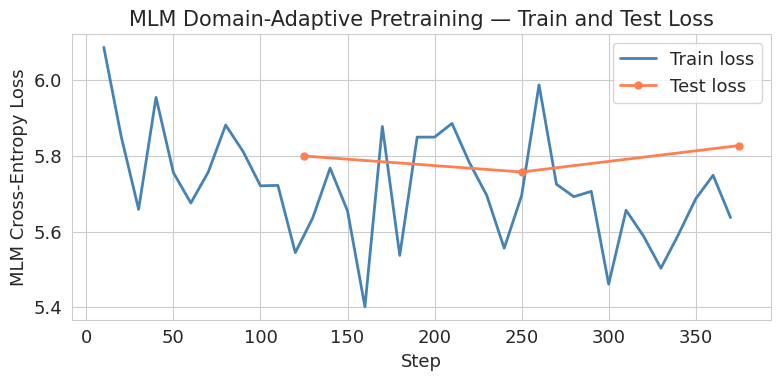

Final train loss: 5.6371
Final test loss:  5.8274
→ Lower MLM loss = the model better predicts masked DNA tokens from surrounding context


In [19]:
# ── Visualization: MLM Training and Test Loss ──
mlm_train_steps = [e["step"] for e in mlm_log_history if "loss" in e and "eval_loss" not in e]
mlm_train_vals  = [e["loss"]  for e in mlm_log_history if "loss" in e and "eval_loss" not in e]
mlm_eval_steps  = [e["step"]  for e in mlm_log_history if "eval_loss" in e]
mlm_eval_vals   = [e["eval_loss"] for e in mlm_log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlm_train_steps, mlm_train_vals, linewidth=2, color="steelblue", label="Train loss")
if mlm_eval_vals:
    ax.plot(mlm_eval_steps, mlm_eval_vals, linewidth=2, color="coral",
            marker="o", markersize=5, label="Test loss")
ax.set_xlabel("Step")
ax.set_ylabel("MLM Cross-Entropy Loss")
ax.set_title("MLM Domain-Adaptive Pretraining — Train and Test Loss")
ax.legend()
plt.tight_layout()
plt.show()

if mlm_train_vals:
    print(f"Final train loss: {mlm_train_vals[-1]:.4f}")
if mlm_eval_vals:
    print(f"Final test loss:  {mlm_eval_vals[-1]:.4f}")
print("→ Lower MLM loss = the model better predicts masked DNA tokens from surrounding context")

---
## Section 3: Frozen Foundation-Model Embeddings for SNP Prediction

This is the **main classification lab**. We use the pretrained Nucleotide Transformer as a frozen feature extractor, then train simple classifiers on top.

**Transfer learning recipe:**
```
ref ──→ [Frozen NT] ──→ mean-pool ──→ emb_ref ──┐
                                                  ├→ [ref; alt; delta; tissue; TSS] → Classifier → P(causal)
alt ──→ [Frozen NT] ──→ mean-pool ──→ emb_alt ──┘
```

The **delta embedding** `alt_emb - ref_emb` captures the direction of change caused by the SNP in the representation space. This is the key signal for predicting functional effect.

In [20]:
# Load the frozen Nucleotide Transformer and inspect parameters
# (reuse nt_model loaded above)
total_params = sum(p.numel() for p in nt_model.parameters())
print(f"Total parameters: {total_params:,} ({total_params/1e6:.1f}M)")

# Count parameters by component
param_groups = {}
for name, p in nt_model.named_parameters():
    group = name.split(".")[0]  # top-level module
    if "embed" in name.lower():
        group = "embeddings"
    elif "layer" in name.lower() or "encoder" in name.lower():
        group = "encoder_layers"
    elif "lm_head" in name.lower() or "cls" in name.lower():
        group = "mlm_head"
    param_groups[group] = param_groups.get(group, 0) + p.numel()

print("\nParameter breakdown:")
for group, count in sorted(param_groups.items(), key=lambda x: -x[1]):
    print(f"  {group}: {count:,} ({count/total_params*100:.1f}%)")

Total parameters: 55,904,972 (55.9M)

Parameter breakdown:
  encoder_layers: 50,382,848 (90.1%)
  embeddings: 3,152,384 (5.6%)
  mlm_head: 2,369,547 (4.2%)
  esm: 193 (0.0%)


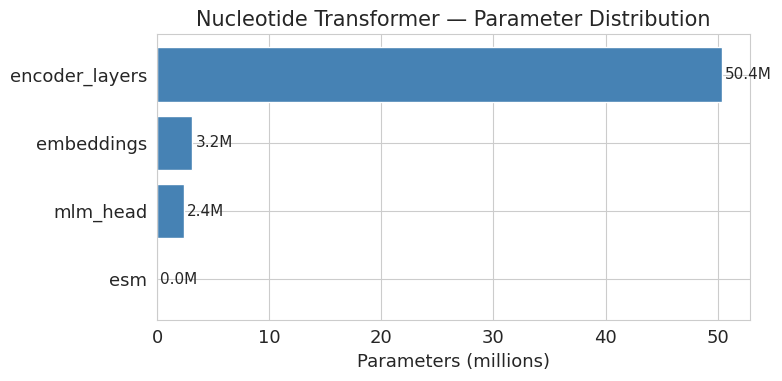

In [21]:
# ── Visualization 8: Parameter distribution ──
groups = sorted(param_groups.items(), key=lambda x: -x[1])
names, counts = zip(*groups)
counts_m = [c / 1e6 for c in counts]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(range(len(names)-1, -1, -1), counts_m, color="steelblue", edgecolor="white")
ax.set_yticks(range(len(names)-1, -1, -1))
ax.set_yticklabels(names)
ax.set_xlabel("Parameters (millions)")
ax.set_title("Nucleotide Transformer — Parameter Distribution")
for i, (bar, cm) in enumerate(zip(bars, counts_m)):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{cm:.1f}M", va="center", fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
# ── Extract embeddings for train and test sets ──
import os

EMB_PATH = "snp_embeddings.pt"

if USE_PRECOMPUTED and os.path.exists(EMB_PATH):
    print("Loading precomputed embeddings...")
    emb_data = torch.load(EMB_PATH, weights_only=True)
    ref_embs_train = emb_data["ref_train"]
    alt_embs_train = emb_data["alt_train"]
    ref_embs_test = emb_data["ref_test"]
    alt_embs_test = emb_data["alt_test"]
else:
    print("Extracting embeddings (this may take a few minutes on GPU)...")

    ref_seqs_train = [ex["ref_forward_sequence"] for ex in train_ds]
    alt_seqs_train = [ex["alt_forward_sequence"] for ex in train_ds]
    ref_seqs_test = [ex["ref_forward_sequence"] for ex in test_ds]
    alt_seqs_test = [ex["alt_forward_sequence"] for ex in test_ds]

    ref_embs_train = extract_embeddings(nt_model, tokenizer, ref_seqs_train, device)
    print(f"  ref_train: {ref_embs_train.shape}")
    alt_embs_train = extract_embeddings(nt_model, tokenizer, alt_seqs_train, device)
    print(f"  alt_train: {alt_embs_train.shape}")
    ref_embs_test = extract_embeddings(nt_model, tokenizer, ref_seqs_test, device)
    print(f"  ref_test: {ref_embs_test.shape}")
    alt_embs_test = extract_embeddings(nt_model, tokenizer, alt_seqs_test, device)
    print(f"  alt_test: {alt_embs_test.shape}")

    # Save for reuse
    torch.save({
        "ref_train": ref_embs_train, "alt_train": alt_embs_train,
        "ref_test": ref_embs_test, "alt_test": alt_embs_test,
    }, EMB_PATH)
    print(f"Saved embeddings to {EMB_PATH}")

print(f"\nEmbedding shapes — ref_train: {ref_embs_train.shape}, alt_train: {alt_embs_train.shape}")

Extracting embeddings (this may take a few minutes on GPU)...
  ref_train: torch.Size([4000, 512])
  alt_train: torch.Size([4000, 512])
  ref_test: torch.Size([800, 512])
  alt_test: torch.Size([800, 512])
Saved embeddings to snp_embeddings.pt

Embedding shapes — ref_train: torch.Size([4000, 512]), alt_train: torch.Size([4000, 512])


In [23]:
# Compute delta embeddings and build feature matrices
delta_train = alt_embs_train - ref_embs_train
delta_test = alt_embs_test - ref_embs_test

# Tissue one-hot encoding
all_tissues = sorted(set(ex["tissue"] for ex in train_ds) | set(ex["tissue"] for ex in test_ds))
tissue_to_idx = {t: i for i, t in enumerate(all_tissues)}
n_tissues = len(all_tissues)
print(f"Number of unique tissues: {n_tissues}")

def make_tissue_onehot(dataset, tissue_to_idx, n_tissues):
    onehot = np.zeros((len(dataset), n_tissues), dtype=np.float32)
    for i, ex in enumerate(dataset):
        if ex["tissue"] in tissue_to_idx:
            onehot[i, tissue_to_idx[ex["tissue"]]] = 1.0
    return torch.tensor(onehot)

tissue_train = make_tissue_onehot(train_ds, tissue_to_idx, n_tissues)
tissue_test = make_tissue_onehot(test_ds, tissue_to_idx, n_tissues)

# Distance to TSS (log-scaled)
tss_train = torch.tensor([np.log10(max(1, ex["distance_to_nearest_tss"])) for ex in train_ds]).unsqueeze(1)
tss_test = torch.tensor([np.log10(max(1, ex["distance_to_nearest_tss"])) for ex in test_ds]).unsqueeze(1)

# Concatenate features: [ref_emb; alt_emb; delta; tissue_onehot; log_tss]
X_train = torch.cat([ref_embs_train, alt_embs_train, delta_train, tissue_train, tss_train], dim=1).numpy()
X_test = torch.cat([ref_embs_test, alt_embs_test, delta_test, tissue_test, tss_test], dim=1).numpy()
y_train = np.array([ex["label"] for ex in train_ds])
y_test = np.array([ex["label"] for ex in test_ds])

print(f"Feature matrix shapes — X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Label distribution — train: {np.bincount(y_train)}, test: {np.bincount(y_test)}")

Number of unique tissues: 49
Feature matrix shapes — X_train: (4000, 1586), X_test: (800, 1586)
Label distribution — train: [1968 2032], test: [383 417]


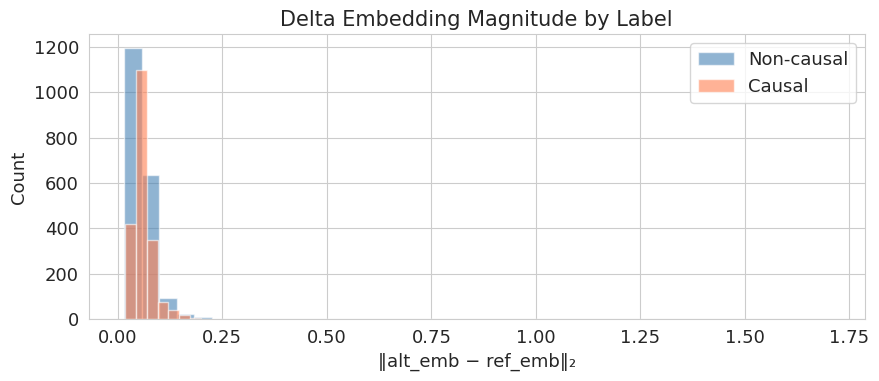

→ If causal variants produce larger embedding deltas, the model has learned something about variant impact


In [24]:
# ── Visualization 9: Delta embedding ‖δ‖₂ distribution by label ──
delta_norms_train = torch.norm(delta_train, dim=1).numpy()

plt.figure(figsize=(9, 4))
for label, color, name in [(0, "steelblue", "Non-causal"), (1, "coral", "Causal")]:
    mask = y_train == label
    plt.hist(delta_norms_train[mask], bins=40, alpha=0.6, color=color, label=name, edgecolor="white")
plt.xlabel("‖alt_emb − ref_emb‖₂")
plt.ylabel("Count")
plt.title("Delta Embedding Magnitude by Label")
plt.legend()
plt.tight_layout()
plt.show()
print("→ If causal variants produce larger embedding deltas, the model has learned something about variant impact")

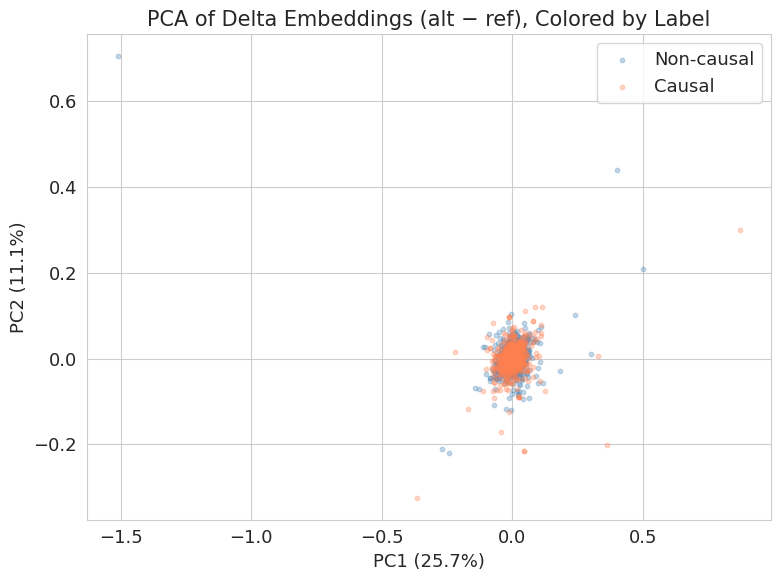

In [25]:
# ── Visualization 10: PCA of delta embeddings ──
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
delta_pca_train = pca.fit_transform(delta_train.numpy())

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "steelblue", "Non-causal"), (1, "coral", "Causal")]:
    mask = y_train == label
    ax.scatter(delta_pca_train[mask, 0], delta_pca_train[mask, 1],
               c=color, alpha=0.3, s=10, label=name)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA of Delta Embeddings (alt − ref), Colored by Label")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# ── Logistic Regression baseline ──
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_model.fit(X_train, y_train)

lr_probs_test = lr_model.predict_proba(X_test)[:, 1]
lr_auroc = roc_auc_score(y_test, lr_probs_test)
lr_auprc = average_precision_score(y_test, lr_probs_test)
print(f"Logistic Regression — AUROC: {lr_auroc:.4f}, AUPRC: {lr_auprc:.4f}")

Logistic Regression — AUROC: 0.6864, AUPRC: 0.7373


In [27]:
# ── Tiny MLP classifier ──
import torch.nn as nn

class SNPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

MLP_PATH = "mlp_classifier.pt"

input_dim = X_train.shape[1]
mlp = SNPClassifier(input_dim).to(device)

if USE_PRECOMPUTED and os.path.exists(MLP_PATH):
    mlp.load_state_dict(torch.load(MLP_PATH, map_location=device, weights_only=True))
    print("Loaded precomputed MLP checkpoint")
    mlp_losses = []
    mlp_test_losses = []
else:
    # Compute class weight for BCE
    pos_count = y_train.sum()
    neg_count = len(y_train) - pos_count
    pos_weight = torch.tensor([neg_count / max(pos_count, 1)], device=device, dtype=torch.float32)

    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

    mlp_losses = []
    mlp_test_losses = []
    n_epochs = 50
    batch_size = 256
    for epoch in range(n_epochs):
        mlp.train()
        perm = torch.randperm(len(X_train_t), device=device)
        epoch_loss = 0
        n_batches = 0
        for i in range(0, len(X_train_t), batch_size):
            idx = perm[i:i+batch_size]
            logits = mlp(X_train_t[idx]).squeeze(-1)
            loss = criterion(logits, y_train_t[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        mlp_losses.append(epoch_loss / n_batches)

        # Test loss
        mlp.eval()
        with torch.no_grad():
            test_logits = mlp(X_test_t).squeeze(-1)
            test_loss = criterion(test_logits, y_test_t)
        mlp_test_losses.append(test_loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs} — train: {mlp_losses[-1]:.4f}  test: {mlp_test_losses[-1]:.4f}")

    torch.save(mlp.state_dict(), MLP_PATH)
    print(f"Saved MLP to {MLP_PATH}")

  Epoch 10/50 — train: 0.5905  test: 0.6066
  Epoch 20/50 — train: 0.5706  test: 0.6089
  Epoch 30/50 — train: 0.5629  test: 0.6165
  Epoch 40/50 — train: 0.5479  test: 0.6185
  Epoch 50/50 — train: 0.5445  test: 0.6335
Saved MLP to mlp_classifier.pt


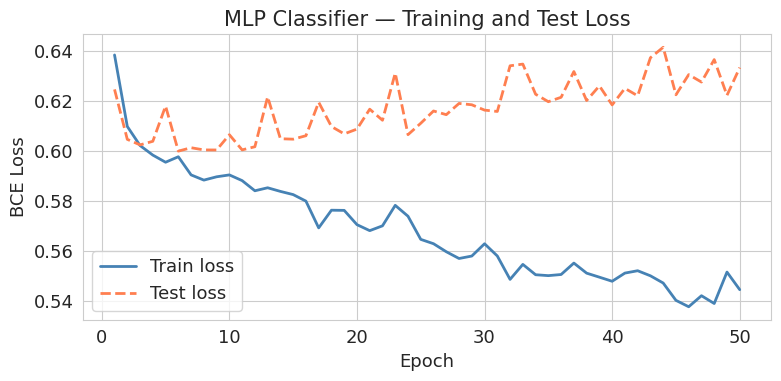

In [28]:
# ── Visualization 11: MLP training and test loss curve ──
if mlp_losses:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(mlp_losses)+1), mlp_losses, linewidth=2, color="steelblue", label="Train loss")
    if mlp_test_losses:
        ax.plot(range(1, len(mlp_test_losses)+1), mlp_test_losses, linewidth=2, color="coral",
                linestyle="--", label="Test loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title("MLP Classifier — Training and Test Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("(Loaded from checkpoint — no training curve available)")

MLP — AUROC: 0.6930, AUPRC: 0.7391


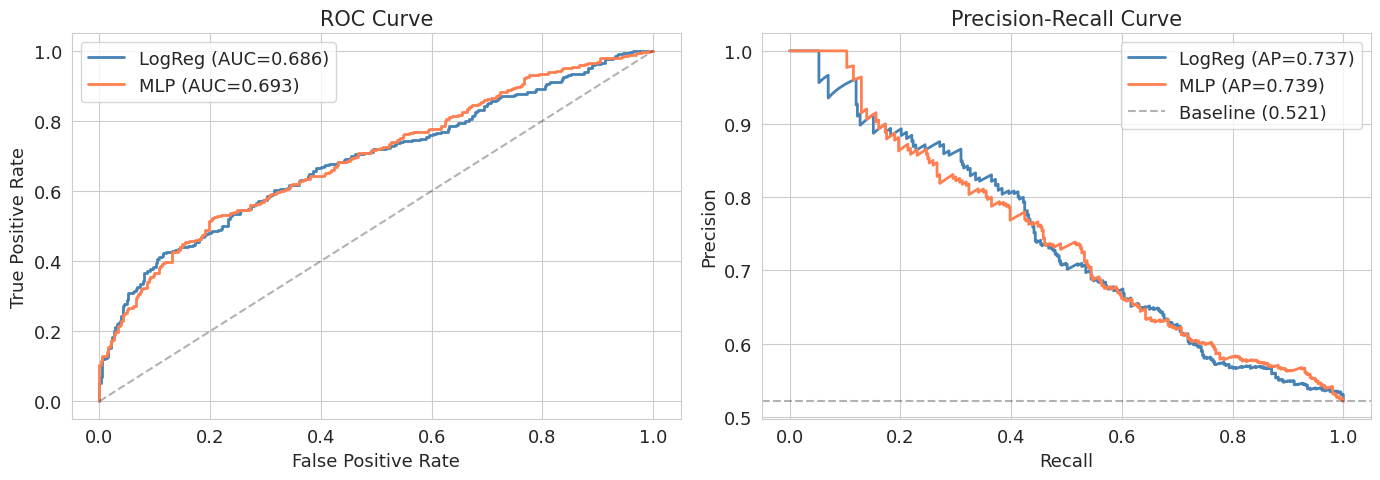

In [29]:
# ── Visualization 12: ROC and PR curves (LR vs MLP) ──
mlp.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
with torch.no_grad():
    mlp_logits = mlp(X_test_t).squeeze(-1).cpu().numpy()
mlp_probs = 1 / (1 + np.exp(-mlp_logits))  # sigmoid

mlp_auroc = roc_auc_score(y_test, mlp_probs)
mlp_auprc = average_precision_score(y_test, mlp_probs)
print(f"MLP — AUROC: {mlp_auroc:.4f}, AUPRC: {mlp_auprc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for probs, label, color in [(lr_probs_test, "LogReg", "steelblue"), (mlp_probs, "MLP", "coral")]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f"{label} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# PR
for probs, label, color in [(lr_probs_test, "LogReg", "steelblue"), (mlp_probs, "MLP", "coral")]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, color=color, linewidth=2, label=f"{label} (AP={ap:.3f})")
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.3, label=f"Baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

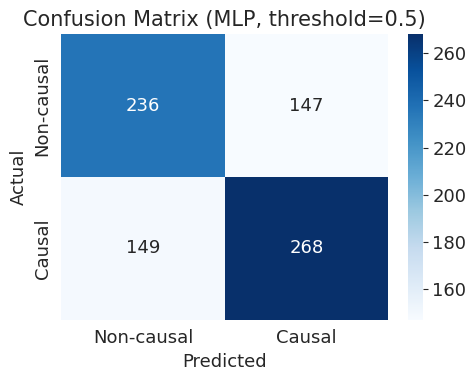

In [30]:
# ── Visualization 13: Confusion matrix ──
mlp_preds = (mlp_probs >= 0.5).astype(int)
cm = confusion_matrix(y_test, mlp_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Non-causal", "Causal"], yticklabels=["Non-causal", "Causal"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (MLP, threshold=0.5)")
plt.tight_layout()
plt.show()

### Frozen Embedding Results Summary

| Model | AUROC | AUPRC | Trainable Params |
|-------|-------|-------|-----------------|
| Logistic Regression | ~varies | ~varies | ~feature_dim |
| MLP (256→64→1) | ~varies | ~varies | ~20K |

Both classifiers use the **same frozen embeddings** from the Nucleotide Transformer. The MLP can learn nonlinear interactions between ref/alt embeddings that logistic regression cannot.

---
## Section 4: Lightweight Fine-Tuning with LoRA

So far we kept the foundation model **frozen** and only trained a small head. Now we **fine-tune** the transformer itself — but efficiently, using **LoRA**.

### LoRA Recap

Instead of updating all weights $W_0 \in \mathbb{R}^{d \times k}$, LoRA adds a low-rank perturbation:

$$W = W_0 + \frac{\alpha}{r} B A$$

where $A \in \mathbb{R}^{r \times k}$, $B \in \mathbb{R}^{d \times r}$, and $r \ll \min(d,k)$.

- $B$ initialized to zero (so the pretrained weights are preserved at start of fine-tuning)
- $A$ initialized from a Gaussian
- Only $A$ and $B$ are trained — typically < 1% of total parameters

In [31]:
# ── Load model for sequence classification + apply LoRA ──
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

# Fresh model instance for classification
nt_clf = AutoModelForSequenceClassification.from_pretrained(
    nt_model_name,
    num_labels=2,
    trust_remote_code=True,
)
nt_clf = nt_clf.to(device)

# LoRA config targeting attention layers
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    target_modules=["query", "key", "value"],  # attention projection layers
    task_type=TaskType.SEQ_CLS,
)

nt_lora = get_peft_model(nt_clf, lora_config)
nt_lora.print_trainable_parameters()

Some weights of the model checkpoint at InstaDeepAI/nucleotide-transformer-v2-50m-multi-species were not used when initializing EsmForSequenceClassification: ['lm_head.bias', 'lm_head.decoder.weight', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing EsmForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing EsmForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-v2-50m-multi-species and are newly initialized: ['classifier.dense.bias', 'c

trainable params: 558,594 || all params: 54,356,677 || trainable%: 1.0276


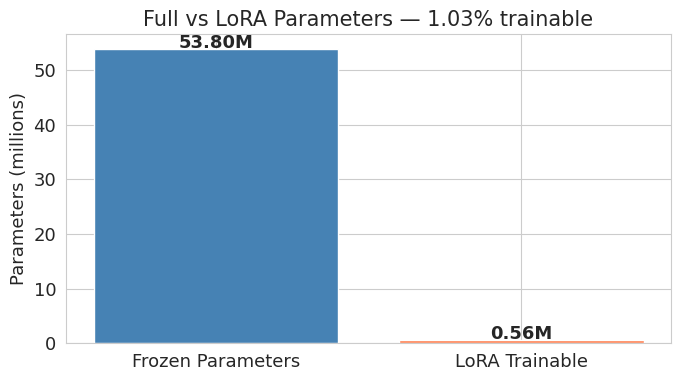

In [32]:
# ── Visualization 14: Full vs LoRA parameter count ──
total_p = sum(p.numel() for p in nt_lora.parameters())
trainable_p = sum(p.numel() for p in nt_lora.parameters() if p.requires_grad)
frozen_p = total_p - trainable_p

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Frozen Parameters", "LoRA Trainable"], [frozen_p/1e6, trainable_p/1e6],
              color=["steelblue", "coral"], edgecolor="white")
ax.set_ylabel("Parameters (millions)")
ax.set_title(f"Full vs LoRA Parameters — {trainable_p/total_p*100:.2f}% trainable")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.2f}M", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [33]:
# ── Tokenize dataset for HF Trainer ──
# For sequence classification, we concatenate ref and alt with a separator
# and let the model learn to compare them

SEP = tokenizer.eos_token or tokenizer.pad_token

def tokenize_for_classification(examples):
    # Concatenate ref [SEP] alt as a single input
    texts = []
    for ref, alt in zip(examples["ref_forward_sequence"], examples["alt_forward_sequence"]):
        texts.append(ref + SEP + alt)
    encoded = tokenizer(texts, truncation=True, padding="max_length", max_length=512)
    encoded["labels"] = examples["label"]
    return encoded

# Use a reduced subset for LoRA training (speed in classroom)
lora_train_ds = train_ds.select(range(min(2000, len(train_ds))))
lora_test_ds = test_ds.select(range(min(400, len(test_ds))))

lora_train_tok = lora_train_ds.map(tokenize_for_classification, batched=True, remove_columns=lora_train_ds.column_names)
lora_test_tok = lora_test_ds.map(tokenize_for_classification, batched=True, remove_columns=lora_test_ds.column_names)

lora_train_tok.set_format("torch")
lora_test_tok.set_format("torch")
print(f"Tokenized — train: {len(lora_train_tok)}, test: {len(lora_test_tok)}")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenized — train: 2000, test: 400


In [34]:
# ── Train with HF Trainer ──
from transformers import TrainingArguments, Trainer

LORA_DIR = "nt_lora_eqtl"

if USE_PRECOMPUTED and os.path.exists(LORA_DIR):
    from peft import PeftModel
    nt_clf_fresh = AutoModelForSequenceClassification.from_pretrained(
        nt_model_name, num_labels=2, trust_remote_code=True,
    ).to(device)
    nt_lora = PeftModel.from_pretrained(nt_clf_fresh, LORA_DIR).to(device)
    print(f"Loaded LoRA checkpoint from {LORA_DIR}")
    lora_log_history = []
else:
    training_args = TrainingArguments(
        output_dir=LORA_DIR,
        num_train_epochs=5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        learning_rate=2e-4,
        weight_decay=0.01,
        logging_steps=20,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED,
    )

    trainer = Trainer(
        model=nt_lora,
        args=training_args,
        train_dataset=lora_train_tok,
        eval_dataset=lora_test_tok,
    )

    trainer.train()
    lora_log_history = trainer.state.log_history

    # Save adapter
    nt_lora.save_pretrained(LORA_DIR)
    print(f"Saved LoRA adapter to {LORA_DIR}")

Epoch,Training Loss,Validation Loss
1,0.660500,0.632756
2,0.541700,0.615706
3,0.520600,0.671123
4,0.406300,0.732890
5,0.306500,0.784123


Saved LoRA adapter to nt_lora_eqtl


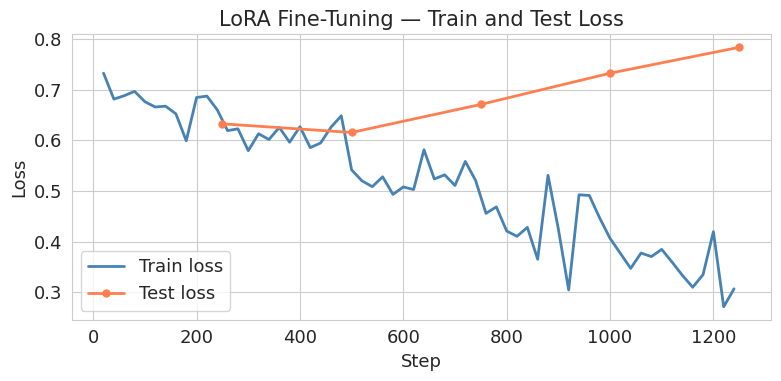

In [35]:
# ── Visualization 15: LoRA fine-tuning train and test loss curve ──
if lora_log_history:
    train_steps = [e["step"] for e in lora_log_history if "loss" in e]
    train_vals = [e["loss"] for e in lora_log_history if "loss" in e]
    eval_steps = [e["step"] for e in lora_log_history if "eval_loss" in e]
    eval_vals = [e["eval_loss"] for e in lora_log_history if "eval_loss" in e]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_steps, train_vals, linewidth=2, color="steelblue", label="Train loss")
    if eval_steps:
        ax.plot(eval_steps, eval_vals, linewidth=2, color="coral", marker="o", markersize=5,
                label="Test loss")
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.set_title("LoRA Fine-Tuning — Train and Test Loss")
    ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("(Loaded from checkpoint — no training curve available)")

In [36]:
# ── Evaluate LoRA model ──
nt_lora.eval()
lora_probs_list = []

from torch.utils.data import DataLoader

eval_loader = DataLoader(lora_test_tok, batch_size=16)
with torch.no_grad():
    for batch in eval_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = nt_lora(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
        lora_probs_list.append(probs)

lora_probs = np.concatenate(lora_probs_list)
lora_y_test = np.array([ex["label"] for ex in lora_test_ds])

lora_auroc = roc_auc_score(lora_y_test, lora_probs)
lora_auprc = average_precision_score(lora_y_test, lora_probs)
print(f"LoRA Model — AUROC: {lora_auroc:.4f}, AUPRC: {lora_auprc:.4f}")

LoRA Model — AUROC: 0.6776, AUPRC: 0.7296


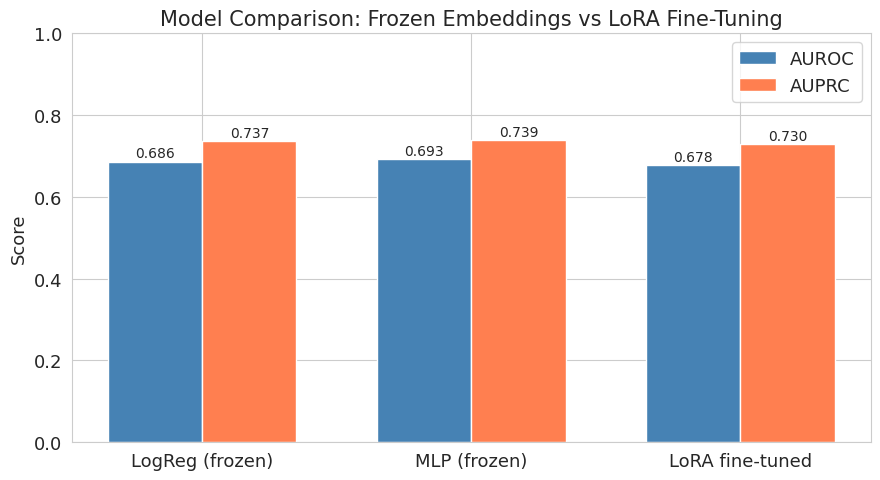

In [37]:
# ── Visualization 16: Model comparison — AUROC and AUPRC ──
models = ["LogReg (frozen)", "MLP (frozen)", "LoRA fine-tuned"]
aurocs = [lr_auroc, mlp_auroc, lora_auroc]
auprcs = [lr_auprc, mlp_auprc, lora_auprc]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, aurocs, width, label="AUROC", color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, auprcs, width, label="AUPRC", color="coral", edgecolor="white")

ax.set_ylabel("Score")
ax.set_title("Model Comparison: Frozen Embeddings vs LoRA Fine-Tuning")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

Extracting LoRA embeddings for PCA comparison...


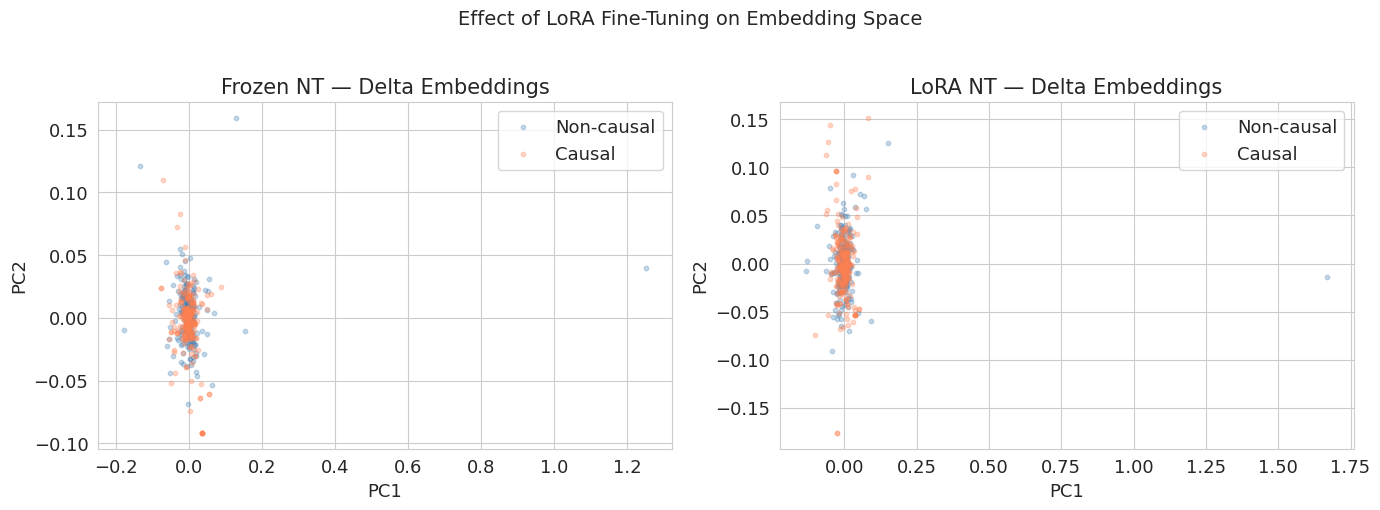

In [38]:
# ── Visualization 17: PCA — Frozen vs LoRA delta embeddings ──
# Extract LoRA embeddings for comparison
print("Extracting LoRA embeddings for PCA comparison...")
# Get the base model from LoRA for embedding extraction
lora_base = nt_lora.base_model.model

# Extract a subset for visualization
n_viz = min(500, len(test_ds))
ref_seqs_viz = [test_ds[i]["ref_forward_sequence"] for i in range(n_viz)]
alt_seqs_viz = [test_ds[i]["alt_forward_sequence"] for i in range(n_viz)]
labels_viz = np.array([test_ds[i]["label"] for i in range(n_viz)])

# LoRA model embeddings (using hidden states)
lora_base.eval()
lora_ref_embs = []
lora_alt_embs = []
with torch.no_grad():
    for i in range(0, n_viz, 16):
        batch_ref = ref_seqs_viz[i:i+16]
        batch_alt = alt_seqs_viz[i:i+16]
        for batch_seqs, emb_list in [(batch_ref, lora_ref_embs), (batch_alt, lora_alt_embs)]:
            enc = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=512)
            enc = {k: v.to(device) for k, v in enc.items()}
            out = lora_base(**enc, output_hidden_states=True)
            hidden = out.hidden_states[-1]
            mask = enc["attention_mask"].unsqueeze(-1).float()
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
            emb_list.append(pooled.cpu())

lora_ref_embs = torch.cat(lora_ref_embs)
lora_alt_embs = torch.cat(lora_alt_embs)
lora_delta = (lora_alt_embs - lora_ref_embs).numpy()

# Frozen delta (use test embeddings already computed)
frozen_delta = (alt_embs_test[:n_viz] - ref_embs_test[:n_viz]).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, delta, title in [
    (axes[0], frozen_delta, "Frozen NT — Delta Embeddings"),
    (axes[1], lora_delta, "LoRA NT — Delta Embeddings"),
]:
    pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(delta)
    for label, color, name in [(0, "steelblue", "Non-causal"), (1, "coral", "Causal")]:
        mask = labels_viz == label
        ax.scatter(pca_2d[mask, 0], pca_2d[mask, 1], c=color, alpha=0.3, s=10, label=name)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

plt.suptitle("Effect of LoRA Fine-Tuning on Embedding Space", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 5: Demo — Enformer and DeepSEA

*This section uses precomputed results — these models are too large for live inference on a T4.*

### Sequence-to-Function Models

Unlike the Nucleotide Transformer (which learns representations via MLM), **Enformer** and **DeepSEA** are trained to directly predict functional outputs from DNA:

- **DeepSEA** (2015): CNN, 2,000 bp input → 2,002 chromatin features
- **Enformer** (2021): Transformer, 393,216 bp input → gene expression + chromatin tracks across 5,313 features

In [39]:
# ── Precomputed Enformer variant effect results ──
# In a real workshop, these would be loaded from shipped JSON files.
# Here we create synthetic demo data to illustrate the concept.

demo_variants = [
    {"id": "rs1421085 (FTO)", "chr": "chr16", "pos": 53800954, "ref": "T", "alt": "C"},
    {"id": "rs7903146 (TCF7L2)", "chr": "chr10", "pos": 114758349, "ref": "C", "alt": "T"},
    {"id": "rs12913832 (HERC2)", "chr": "chr15", "pos": 28365618, "ref": "A", "alt": "G"},
    {"id": "rs334 (HBB/sickle)", "chr": "chr11", "pos": 5248232, "ref": "T", "alt": "A"},
    {"id": "rs1800497 (DRD2)", "chr": "chr11", "pos": 113400106, "ref": "G", "alt": "A"},
]

demo_tissues = [
    "Adipose", "Blood", "Brain", "Heart", "Liver",
    "Lung", "Muscle", "Pancreas", "Skin", "Thyroid",
]

# Synthetic Enformer VES (illustrative — not real predictions)
np.random.seed(42)
enformer_ves = np.random.randn(len(demo_variants), len(demo_tissues)) * 0.5
# Make FTO show strong adipose signal
enformer_ves[0, 0] = 2.1  # Adipose
enformer_ves[0, 7] = 1.4  # Pancreas
# Make TCF7L2 show pancreas signal
enformer_ves[1, 7] = 1.8
# Make HBB show blood signal
enformer_ves[3, 1] = -2.5
# Make HERC2 show skin signal
enformer_ves[2, 8] = 1.6

print("Loaded precomputed Enformer VES for", len(demo_variants), "variants ×", len(demo_tissues), "tissues")

Loaded precomputed Enformer VES for 5 variants × 10 tissues


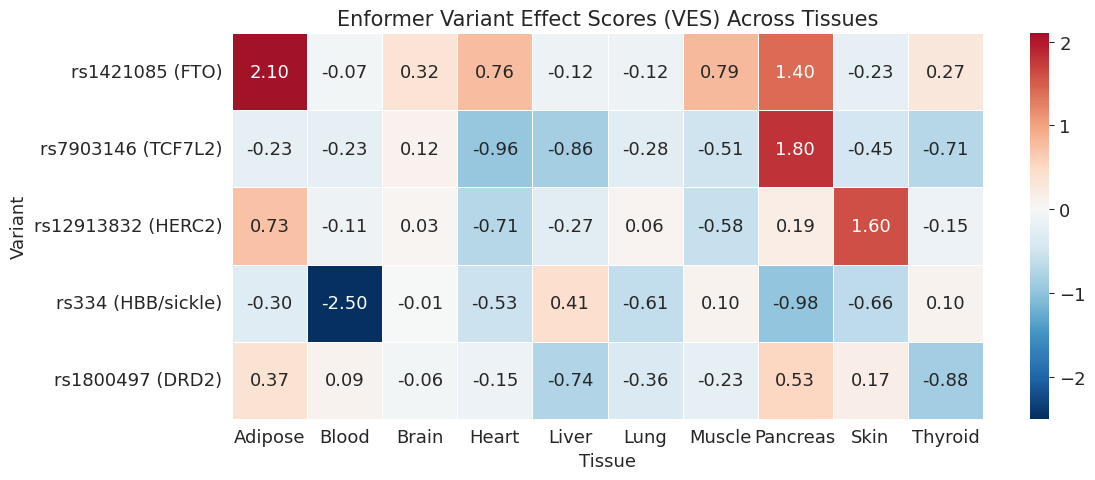

→ Each cell shows f(alt) − f(ref) for that variant-tissue pair
→ Strong signals indicate the variant disrupts regulatory activity in that tissue


In [40]:
# ── Visualization 18: Enformer VES heatmap across tissues ──
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    enformer_ves, ax=ax,
    xticklabels=demo_tissues,
    yticklabels=[v["id"] for v in demo_variants],
    cmap="RdBu_r", center=0, annot=True, fmt=".2f",
    linewidths=0.5, linecolor="white",
)
ax.set_title("Enformer Variant Effect Scores (VES) Across Tissues")
ax.set_xlabel("Tissue")
ax.set_ylabel("Variant")
plt.tight_layout()
plt.show()
print("→ Each cell shows f(alt) − f(ref) for that variant-tissue pair")
print("→ Strong signals indicate the variant disrupts regulatory activity in that tissue")

### DeepSEA: The Short-Context Counterpart

DeepSEA uses only **2,000 bp** of context (vs Enformer's 393,216 bp). It predicts **chromatin features** (histone marks, DNase sensitivity, TF binding) rather than gene expression.

**When to use which?**

| Feature | DeepSEA | Nucleotide Transformer | Enformer |
|---------|---------|----------------------|----------|
| Input size | 2,000 bp | ~6,000 bp (1024 tokens) | 393,216 bp |
| Architecture | CNN | Transformer (encoder) | Transformer |
| Pretraining | Supervised (chromatin) | Self-supervised (MLM) | Supervised (expression) |
| Output | Chromatin features | Embeddings | Expression tracks |
| Best for | Local regulatory grammar | Transfer learning | Long-range regulation |

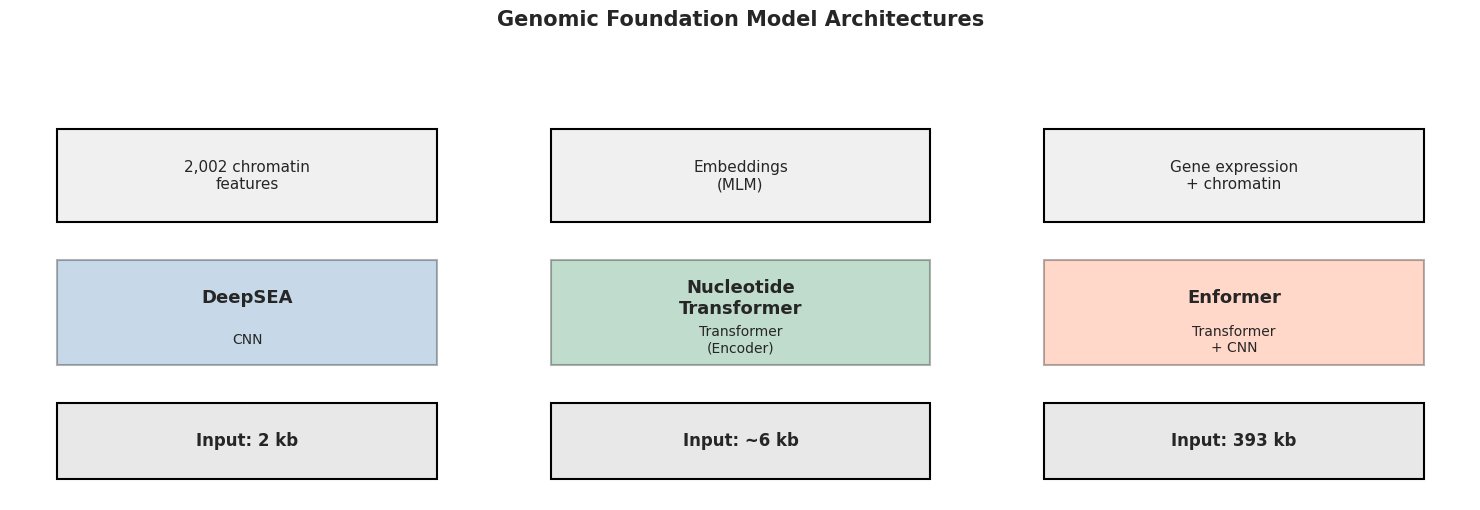

In [41]:
# ── Visualization 19: Architecture comparison diagram ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_info = [
    ("DeepSEA", "CNN", "2 kb", "2,002 chromatin\nfeatures", "steelblue"),
    ("Nucleotide\nTransformer", "Transformer\n(Encoder)", "~6 kb", "Embeddings\n(MLM)", "seagreen"),
    ("Enformer", "Transformer\n+ CNN", "393 kb", "Gene expression\n+ chromatin", "coral"),
]

for ax, (name, arch, inp_size, output, color) in zip(axes, models_info):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    # Input box
    ax.add_patch(plt.Rectangle((1, 0.5), 8, 1.8, facecolor="#e8e8e8", edgecolor="black", linewidth=1.5))
    ax.text(5, 1.4, f"Input: {inp_size}", ha="center", va="center", fontsize=12, fontweight="bold")

    # Arrow
    ax.annotate("", xy=(5, 3.2), xytext=(5, 2.3), arrowprops=dict(arrowstyle="->", lw=2))

    # Model box
    ax.add_patch(plt.Rectangle((1, 3.2), 8, 2.5, facecolor=color, edgecolor="black", linewidth=1.5, alpha=0.3))
    ax.text(5, 4.8, name, ha="center", va="center", fontsize=13, fontweight="bold")
    ax.text(5, 3.8, arch, ha="center", va="center", fontsize=10)

    # Arrow
    ax.annotate("", xy=(5, 6.6), xytext=(5, 5.7), arrowprops=dict(arrowstyle="->", lw=2))

    # Output box
    ax.add_patch(plt.Rectangle((1, 6.6), 8, 2.2, facecolor="#f0f0f0", edgecolor="black", linewidth=1.5))
    ax.text(5, 7.7, output, ha="center", va="center", fontsize=11)

plt.suptitle("Genomic Foundation Model Architectures", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# ── Visualization 20: Cross-model variant scoring comparison ──
# Synthetic DeepSEA scores for comparison
np.random.seed(123)
deepsea_scores = np.random.randn(len(demo_variants)) * 0.3
deepsea_scores[3] = -1.8  # HBB strong signal
deepsea_scores[0] = 0.9   # FTO moderate signal

# Use max absolute Enformer VES per variant as summary
enformer_max = np.max(np.abs(enformer_ves), axis=1) * np.sign(enformer_ves[np.arange(len(enformer_ves)), np.argmax(np.abs(enformer_ves), axis=1)])

# Display as table
rows = []
for i, v in enumerate(demo_variants):
    rows.append([
        v["id"],
        f"{v['ref']}→{v['alt']}",
        f"{deepsea_scores[i]:.3f}",
        f"{enformer_max[i]:.3f}",
    ])

display_comparison_table(
    rows,
    columns=["Variant", "Change", "DeepSEA (max)", "Enformer (max |VES|)"],
    title="Cross-Model Variant Effect Scores"
)

print("\n→ Enformer captures long-range effects (e.g., FTO enhancer ~1Mb from target)")
print("→ DeepSEA excels at local chromatin disruption (e.g., HBB coding variant)")

Variant,Change,DeepSEA (max),Enformer (max |VES|)
rs1421085 (FTO),T→C,0.900,2.100
rs7903146 (TCF7L2),C→T,0.299,1.800
rs12913832 (HERC2),A→G,0.085,1.600
rs334 (HBB/sickle),T→A,-1.800,-2.500
rs1800497 (DRD2),G→A,-0.174,-0.882



→ Enformer captures long-range effects (e.g., FTO enhancer ~1Mb from target)
→ DeepSEA excels at local chromatin disruption (e.g., HBB coding variant)


---
## Section 6: Interpretation and Attribution

Three approaches to understanding what genomic models have learned:

1. **Attention visualization** — which positions attend to which?
2. **Gradient-based saliency** — which input positions most affect the output?
3. **In silico mutagenesis** — systematically mutate each position and measure the effect

We demonstrate the first two using the Nucleotide Transformer.

In [43]:
# ── Attention around the SNP site ──
# Use the frozen NT model with output_attentions=True
ex = test_ds[0]
ref_seq = ex["ref_forward_sequence"]
snp_pos = find_snp_position(ref_seq, ex["alt_forward_sequence"])

# Tokenize the ref sequence
enc = tokenizer(ref_seq, return_tensors="pt", truncation=True, max_length=512).to(device)
nt_model.eval()
with torch.no_grad():
    out = nt_model(**enc, output_attentions=True)

# Get attention from last layer, average over heads
# Shape: (n_heads, seq_len, seq_len)
last_attn = out.attentions[-1].squeeze(0).cpu().numpy()  # (n_heads, seq_len, seq_len)
avg_attn = last_attn.mean(axis=0)  # (seq_len, seq_len)

# Find which token contains the SNP
token_len = 6  # 6-mer
snp_token_idx = snp_pos // token_len + 1  # +1 for CLS/BOS token
print(f"SNP at base {snp_pos}, token index ~{snp_token_idx}")
print(f"Attention matrix shape: {avg_attn.shape}")

SNP at base 1024, token index ~171
Attention matrix shape: (344, 344)


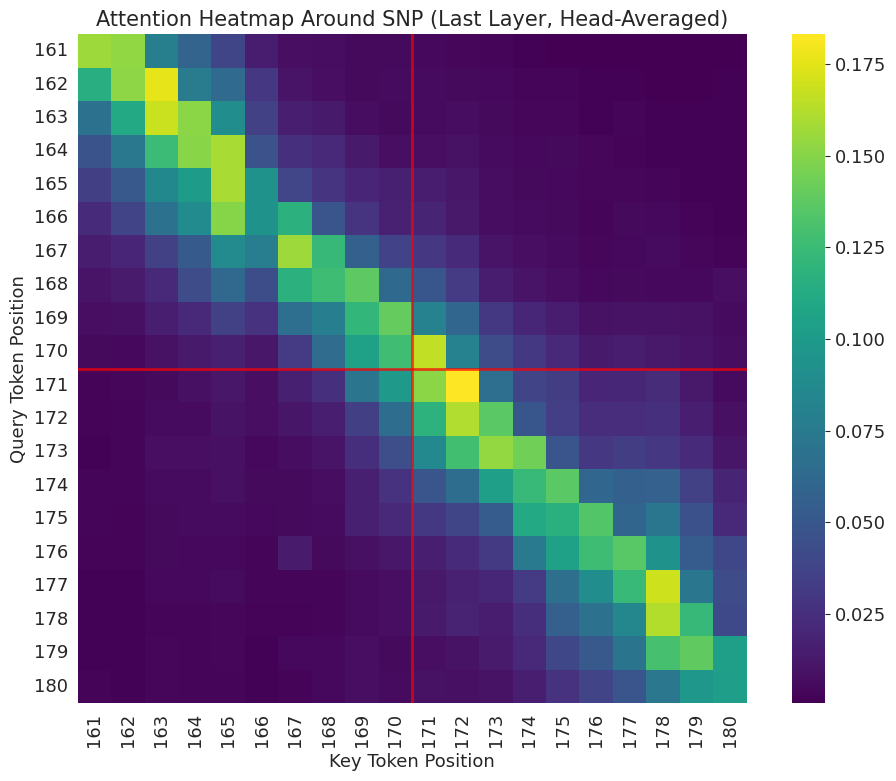

→ Red lines mark the token containing the SNP
→ Look for whether the SNP token attends to (or is attended by) nearby regulatory elements


In [44]:
# ── Visualization 21: Attention heatmap around SNP position ──
# Window of ~20 tokens around the SNP token
window = 10
start_tok = max(0, snp_token_idx - window)
end_tok = min(avg_attn.shape[0], snp_token_idx + window)

attn_window = avg_attn[start_tok:end_tok, start_tok:end_tok]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(attn_window, ax=ax, cmap="viridis", square=True,
            xticklabels=range(start_tok, end_tok),
            yticklabels=range(start_tok, end_tok))

# Mark the SNP token
snp_rel = snp_token_idx - start_tok
if 0 <= snp_rel < len(attn_window):
    ax.axhline(snp_rel, color="red", linewidth=2, alpha=0.7)
    ax.axvline(snp_rel, color="red", linewidth=2, alpha=0.7)

ax.set_xlabel("Key Token Position")
ax.set_ylabel("Query Token Position")
ax.set_title("Attention Heatmap Around SNP (Last Layer, Head-Averaged)")
plt.tight_layout()
plt.show()
print("→ Red lines mark the token containing the SNP")
print("→ Look for whether the SNP token attends to (or is attended by) nearby regulatory elements")

In [45]:
# ── Gradient-based saliency ──
# Compute gradient of the predicted logit w.r.t. input embeddings
nt_model.eval()
enc = tokenizer(ref_seq, return_tensors="pt", truncation=True, max_length=512).to(device)

# Get input embeddings
input_embeds = nt_model.get_input_embeddings()(enc["input_ids"])
input_embeds.requires_grad_(True)
input_embeds.retain_grad()

# Forward pass using inputs_embeds
out = nt_model(inputs_embeds=input_embeds, attention_mask=enc["attention_mask"],
               output_hidden_states=True)

# Use the MLM output at the SNP token position as the target
snp_tok_idx = min(snp_token_idx, out.logits.shape[1] - 1)
target = out.logits[0, snp_tok_idx].sum()
target.backward()

# Saliency = L2 norm of gradient at each token position
saliency = input_embeds.grad[0].norm(dim=-1).detach().cpu().numpy()
print(f"Saliency shape: {saliency.shape} (one score per token)")

Saliency shape: (344,) (one score per token)


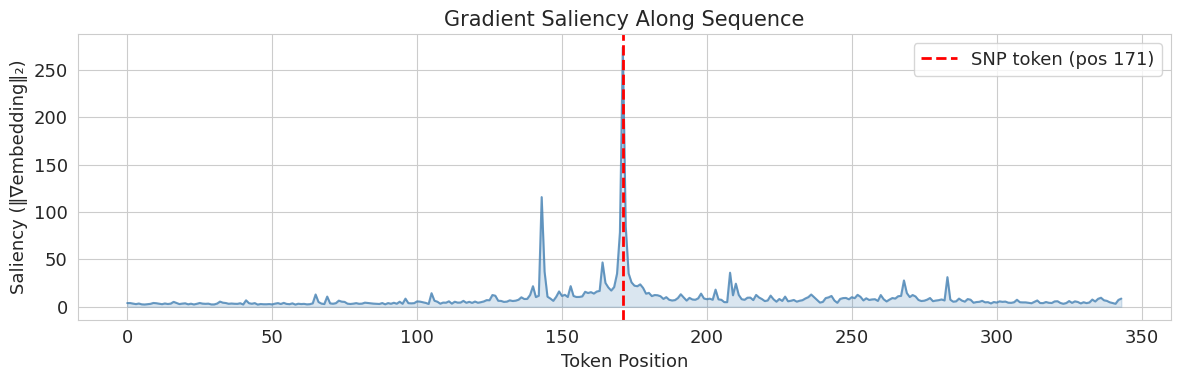

→ High saliency = the model is sensitive to perturbations at this position
→ The SNP position may or may not show the highest saliency — context matters!


In [53]:
# ── Visualization 22: Saliency scores along sequence ──
plt.figure(figsize=(12, 4))
plt.plot(range(len(saliency)), saliency, linewidth=1.5, color="steelblue", alpha=0.8)
plt.fill_between(range(len(saliency)), saliency, alpha=0.2, color="steelblue")

# Mark SNP position
if snp_token_idx < len(saliency):
    plt.axvline(snp_token_idx, color="red", linewidth=2, linestyle="--",
                label=f"SNP token (pos {snp_token_idx})")

plt.xlabel("Token Position")
plt.ylabel("Saliency (‖∇embedding‖₂)")
plt.title("Gradient Saliency Along Sequence")
plt.legend()
plt.tight_layout()
plt.show()
print("→ High saliency = the model is sensitive to perturbations at this position")
print("→ The SNP position may or may not show the highest saliency — context matters!")

### Interpretation Caveats

- **Attention ≠ importance**: high attention weights don't necessarily mean causal influence on the prediction
- **Gradient saliency is local**: it measures sensitivity to infinitesimal changes, not the effect of actual mutations
- **In silico mutagenesis** (not shown) is more reliable but computationally expensive: it requires N forward passes for a sequence of length N
- For production-grade interpretation, consider **integrated gradients** or **DeepLIFT**

---
## Section 7: Wrap-Up

### The Journey

1. **Data** — Inspected an eQTL dataset with ref/alt sequences, tissue labels, and genomic coordinates
2. **Tokenization** — Learned how DNA is tokenized into 6-mers for genomic language models
3. **Embeddings** — Extracted frozen representations from a pretrained Nucleotide Transformer
4. **Frozen Classifiers** — Trained logistic regression and MLP on frozen embeddings
5. **LoRA Fine-Tuning** — Efficiently adapted the foundation model with < 1% trainable parameters
6. **Sequence-to-Function Models** — Saw how Enformer and DeepSEA score variant effects at scale
7. **Interpretation** — Visualized attention and saliency to understand model predictions

In [47]:
# ── Final results summary ──
results_df = pd.DataFrame({
    "Model": ["LogReg (frozen)", "MLP (frozen)", "LoRA fine-tuned"],
    "AUROC": [lr_auroc, mlp_auroc, lora_auroc],
    "AUPRC": [lr_auprc, mlp_auprc, lora_auprc],
    "Trainable Params": [
        f"{X_train.shape[1]:,}",
        f"{sum(p.numel() for p in mlp.parameters()):,}",
        f"{trainable_p:,}",
    ],
})
display(results_df.style.format({"AUROC": "{:.4f}", "AUPRC": "{:.4f}"}).set_caption("Final Model Comparison"))

,Model,AUROC,AUPRC,Trainable Params
0,LogReg (frozen),0.6864,0.7373,"1,586"
1,MLP (frozen),0.6930,0.7391,"422,785"
2,LoRA fine-tuned,0.6776,0.7296,"558,594"


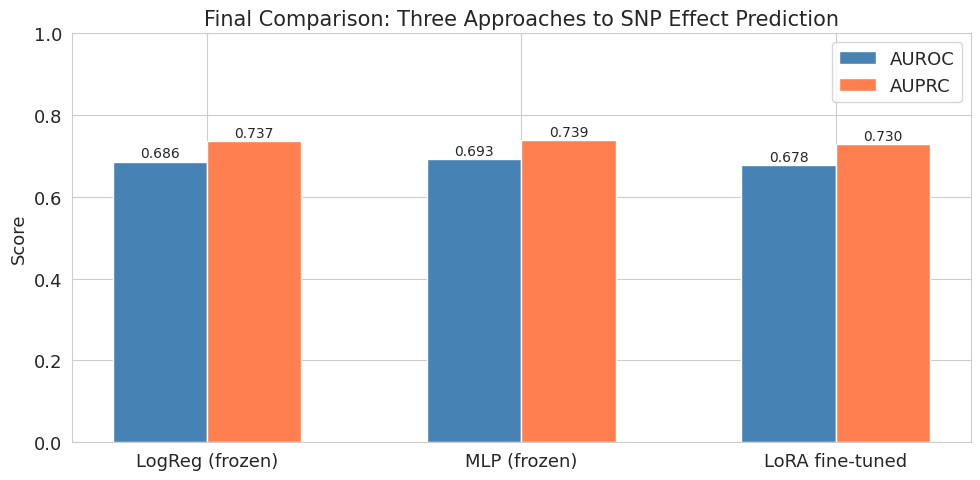

In [48]:
# ── Visualization 23: Final model comparison ──
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.3

bars1 = ax.bar(x - width/2, results_df["AUROC"], width, label="AUROC", color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, results_df["AUPRC"], width, label="AUPRC", color="coral", edgecolor="white")

ax.set_ylabel("Score")
ax.set_title("Final Comparison: Three Approaches to SNP Effect Prediction")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"])
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### NLP vs Genomics: Comparing the Two Modalities

| Aspect | Clinical NLP | Genomics |
|--------|---------------------|-------------------|
| **Data** | Clinical notes (text) | DNA sequences (A/C/G/T) |
| **Tokenization** | BPE subwords (~50k vocab) | 6-mer k-mers (~4k vocab) |
| **Architecture** | Decoder (GPT-style) | Encoder (BERT-style) |
| **Pretraining** | Causal LM (next token) | Masked LM (predict masked) |
| **Task** | Text generation → structured output | Binary classification → variant effect |
| **Scale** | Note-length context (256–2048 tokens) | Genomic context (1,024 tokens ≈ 6 kb) |

### Takeaways

1. **Tokenization matters**: 6-mer tokenization captures local sequence patterns; one-hot encoding preserves single-base resolution
2. **Frozen embeddings are a strong baseline**: pretrained representations transfer well even without fine-tuning
3. **LoRA is efficient**: < 1% of parameters can meaningfully improve task-specific performance
4. **Context length matters**: DeepSEA (2kb), NT (~6kb), and Enformer (393kb) capture different scales of regulatory logic
5. **Interpretation is evolving**: attention and saliency give hints, but causal attribution remains an open research area

### Further Exploration

- Try `variant_effect_pathogenic_clinvar` for clinical/pathogenic variant classification
- Experiment with longer sequence windows (1024, 2048 tokens)
- Explore the larger Nucleotide Transformer models (250M, 500M, 2.5B)
- Look into **AlphaGenome** for the latest from DeepMind
- Read the [Nucleotide Transformer paper](https://www.biorxiv.org/content/10.1101/2023.01.11.523679v1) and [Enformer paper](https://www.nature.com/articles/s41592-021-01252-x)